# Airbnb Price Listing Optimization — Exploratory Data Analysis

**CRISP-DM Phase:** Data Understanding / EDA

**Dataset:** `Listings.csv` (280K listings across 10 global cities) + `Reviews.csv` (5.3M reviews, 2008–2021)

This notebook covers:
1. Data overview & data quality
2. Distribution analysis
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis (including engineered features from `Reviews.csv`)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Listings.csv uses Latin-1 encoding (contains accented city/host names)
listings = pd.read_csv('Listings.csv', encoding='latin1', low_memory=False)
listings.shape

(279712, 33)

In [2]:
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## 1. Data Overview & Quality Check

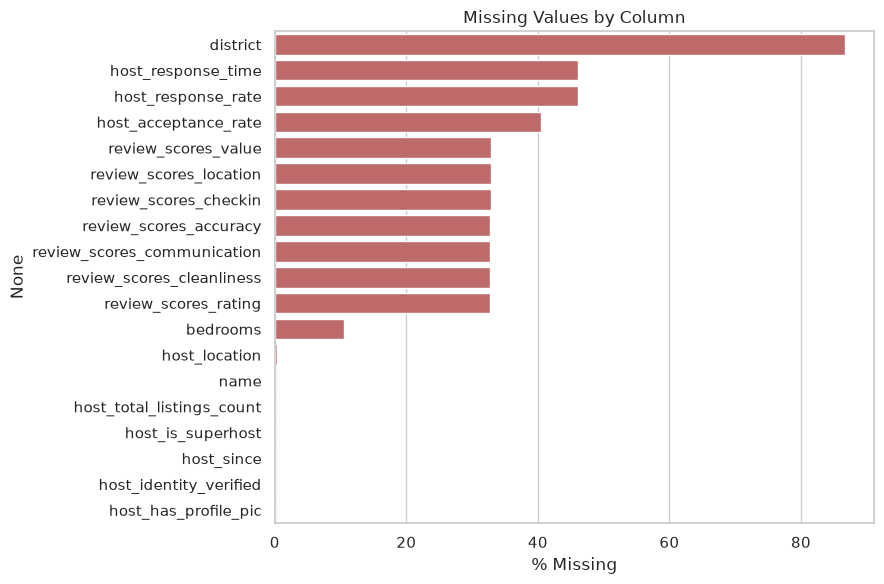

district                       86.8
host_response_time             46.0
host_response_rate             46.0
host_acceptance_rate           40.4
review_scores_value            32.8
review_scores_location         32.8
review_scores_checkin          32.8
review_scores_accuracy         32.8
review_scores_communication    32.8
review_scores_cleanliness      32.8
review_scores_rating           32.7
bedrooms                       10.5
host_location                   0.3
name                            0.1
host_total_listings_count       0.1
host_is_superhost               0.1
host_since                      0.1
host_identity_verified          0.1
host_has_profile_pic            0.1
dtype: float64

In [4]:
missing = (listings.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(9, 6))
sns.barplot(x=missing.values, y=missing.index, color='indianred')
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()
missing.round(1)

**Insight:** `district` is missing in ~87% of rows and should likely be dropped outright. The six `review_scores_*` columns and `review_scores_rating` are all missing in ~33% of rows — almost certainly listings with zero reviews, not random missingness, so they should be treated as "no reviews yet" rather than imputed with a mean. `host_response_rate`/`host_response_time` are missing in ~40–46% of rows (hosts who haven't had a recent guest interaction), and `bedrooms` is missing in ~10.5% of rows.

In [5]:
print("Duplicate listing_id rows:", listings['listing_id'].duplicated().sum())
print("\nprice == 0 rows:", (listings['price'] == 0).sum())
print("price > 10,000 (local currency) rows:", (listings['price'] > 10000).sum())
print("\nUnique cities:", listings['city'].nunique())
listings['city'].value_counts()

Duplicate listing_id rows: 0

price == 0 rows: 113
price > 10,000 (local currency) rows: 1284

Unique cities: 10


city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087
Name: count, dtype: int64

**Insight:** No duplicate `listing_id`s — good, no de-duplication needed. There are 113 listings priced at 0 (clearly invalid, should be removed) and 1,284 listings priced above 10,000 in local currency (likely legitimate ultra-luxury stays and data-entry errors mixed together — needs investigation, not blanket removal). The dataset spans **10 cities across 10 different countries**: Paris, New York, Sydney, Rome, Rio de Janeiro, Istanbul, Mexico City, Bangkok, Cape Town, and Hong Kong.

### ⚠️ Critical data quality issue: mixed currencies

This dataset combines cities from different countries, and **`price` is recorded in each listing's local currency** (not a common currency like USD). This means raw price values are **not directly comparable across cities** — a price of 1,000 in Thai Baht (Bangkok) represents a very different real cost than 1,000 in US Dollars (New York). Any global price analysis, distribution study, or city comparison must account for this before drawing conclusions — either by converting all prices to a common currency using each country's exchange rate, or by analyzing/segmenting price **within each city separately**. We'll do the latter for the parts of this analysis where currency comparability matters.

/tmp/ipykernel_9746/151749238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_price.values, y=city_price.index, palette='rocket')


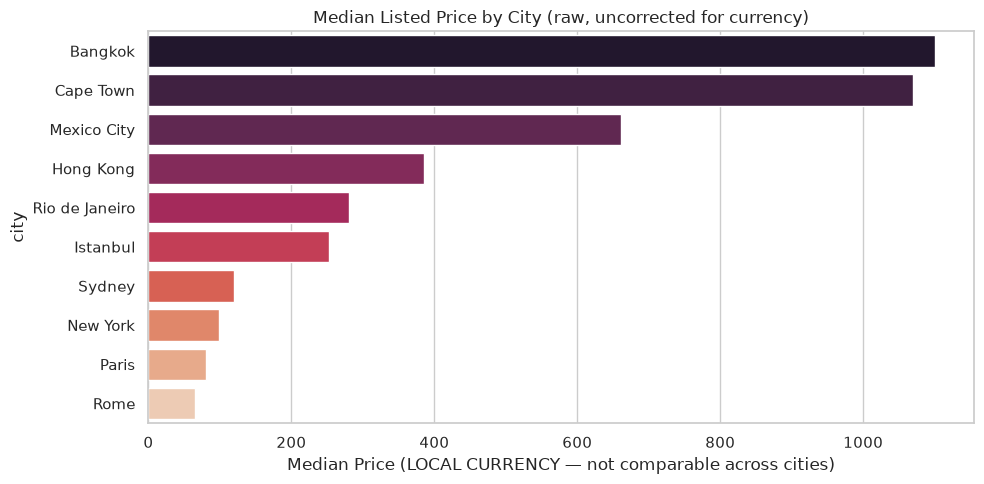

city
Bangkok           1100.0
Cape Town         1069.0
Mexico City        661.0
Hong Kong          386.0
Rio de Janeiro     280.0
Istanbul           252.0
Sydney             120.0
New York            99.0
Paris               80.0
Rome                65.0
Name: price, dtype: float64

In [6]:
city_price = listings.groupby('city')['price'].median().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=city_price.values, y=city_price.index, palette='rocket')
plt.xlabel('Median Price (LOCAL CURRENCY — not comparable across cities)')
plt.title('Median Listed Price by City (raw, uncorrected for currency)')
plt.tight_layout()
plt.show()
city_price.round(1)

**Insight:** Bangkok (~1,049) and Cape Town (~1,000) show the highest raw median prices, while Rome (~65) and Paris (~80) show the lowest — but this gap is driven substantially by currency denomination (Thai Baht and South African Rand have much smaller unit value than Euros), **not** necessarily by Bangkok/Cape Town actually being pricier destinations. Without currency conversion, city-level price comparisons here should be treated as directional at best. For modeling, this also means `city` (or a currency-normalized price) must be an explicit input — a single global price model without a city/currency correction would be fundamentally miscalibrated.

### Preparing a working copy for the rest of the EDA

We remove invalid prices (≤ 0) and cap extreme outliers at each city's 99th percentile (rather than a single global cutoff, given the currency differences above), so that later plots aren't dominated by a handful of extreme values.

In [7]:
df = listings[listings['price'] > 0].copy()

city_cap = df.groupby('city')['price'].transform(lambda x: x.quantile(0.99))
df = df[df['price'] <= city_cap].copy()
print("Rows before cleaning:", len(listings), "| after cleaning:", len(df))

Rows before cleaning: 279712 | after cleaning: 276846


## 2. Distribution Analysis

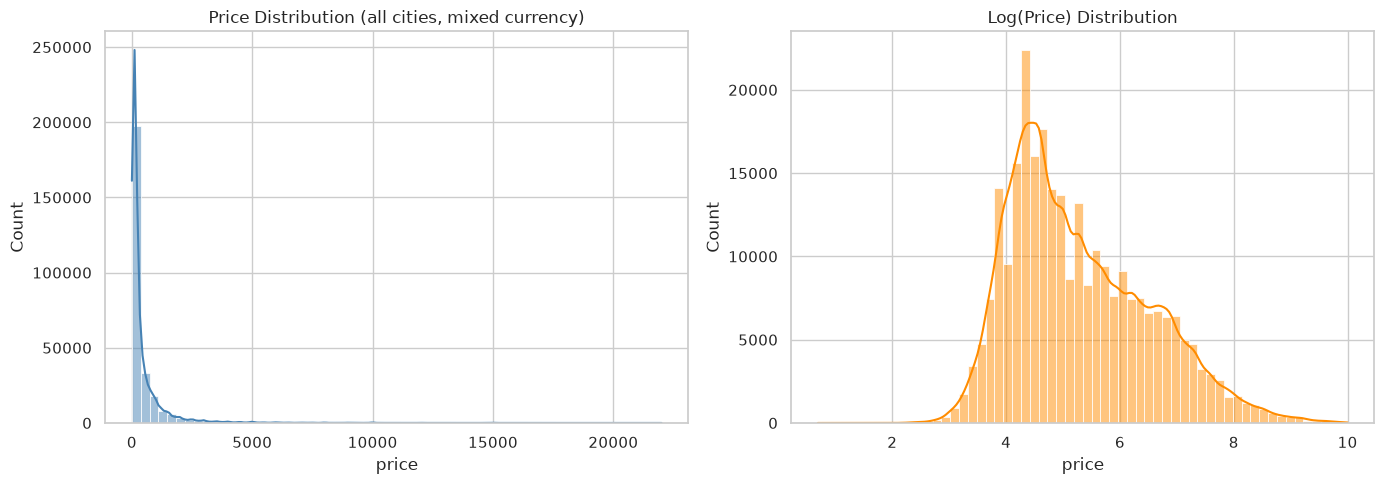

Skewness (price): 7.37
Skewness (log price): 0.68


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['price'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (all cities, mixed currency)')

sns.histplot(np.log1p(df['price']), bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Log(Price) Distribution')
plt.tight_layout()
plt.show()

print("Skewness (price):", round(df['price'].skew(), 2))
print("Skewness (log price):", round(np.log1p(df['price']).skew(), 2))

**Insight:** Even after removing invalid/extreme values, price is still heavily right-skewed (mixing currencies amplifies this further, since 1000+ Baht/Rand values sit alongside <100 Euro/Dollar values on the same axis). The log transform substantially normalizes the shape. **Takeaway:** confirms `log(price)` as the right modeling target — and reinforces that this should ideally be done per-city or on currency-converted prices for a meaningful global distribution.

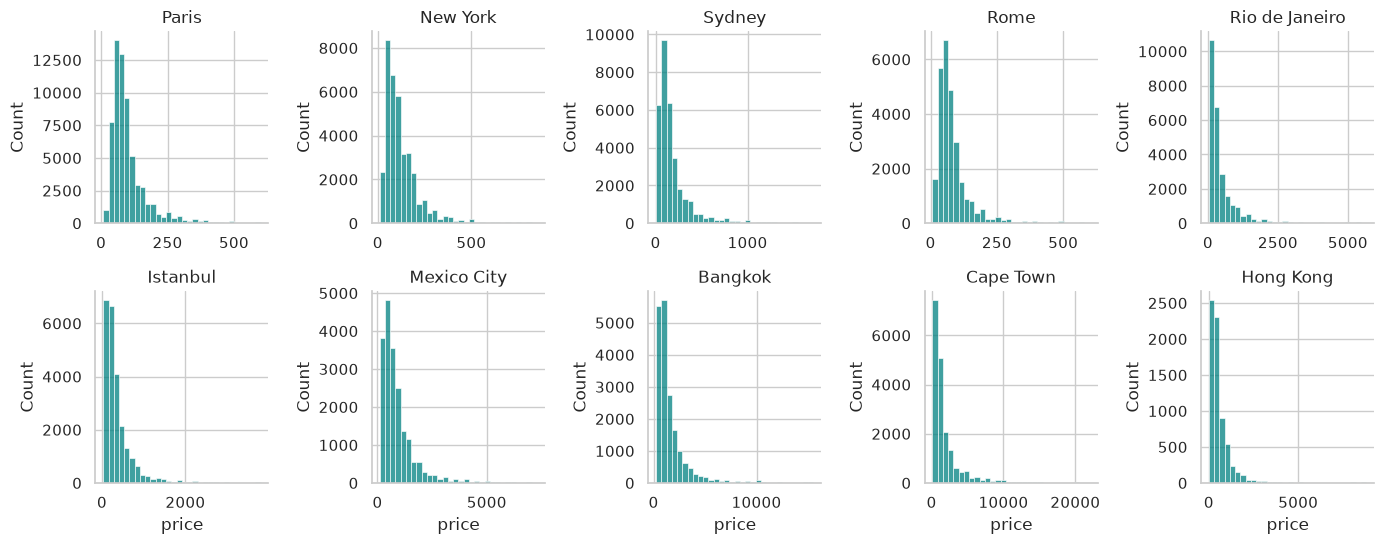

In [9]:
cities_order = df['city'].value_counts().index
g = sns.FacetGrid(df, col='city', col_wrap=5, col_order=cities_order, height=2.8, sharex=False, sharey=False)
g.map(sns.histplot, 'price', bins=30, color='teal')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

**Insight:** Faceting price by city shows each city has its own distinct scale and shape — some (Paris, Rome, New York) cluster tightly in the low hundreds, while others (Bangkok, Cape Town) spread into the thousands purely due to currency. This confirms per-city (or currency-normalized) analysis is the right approach going forward, and that a model should either predict price separately per city or include strong city-level correction terms.

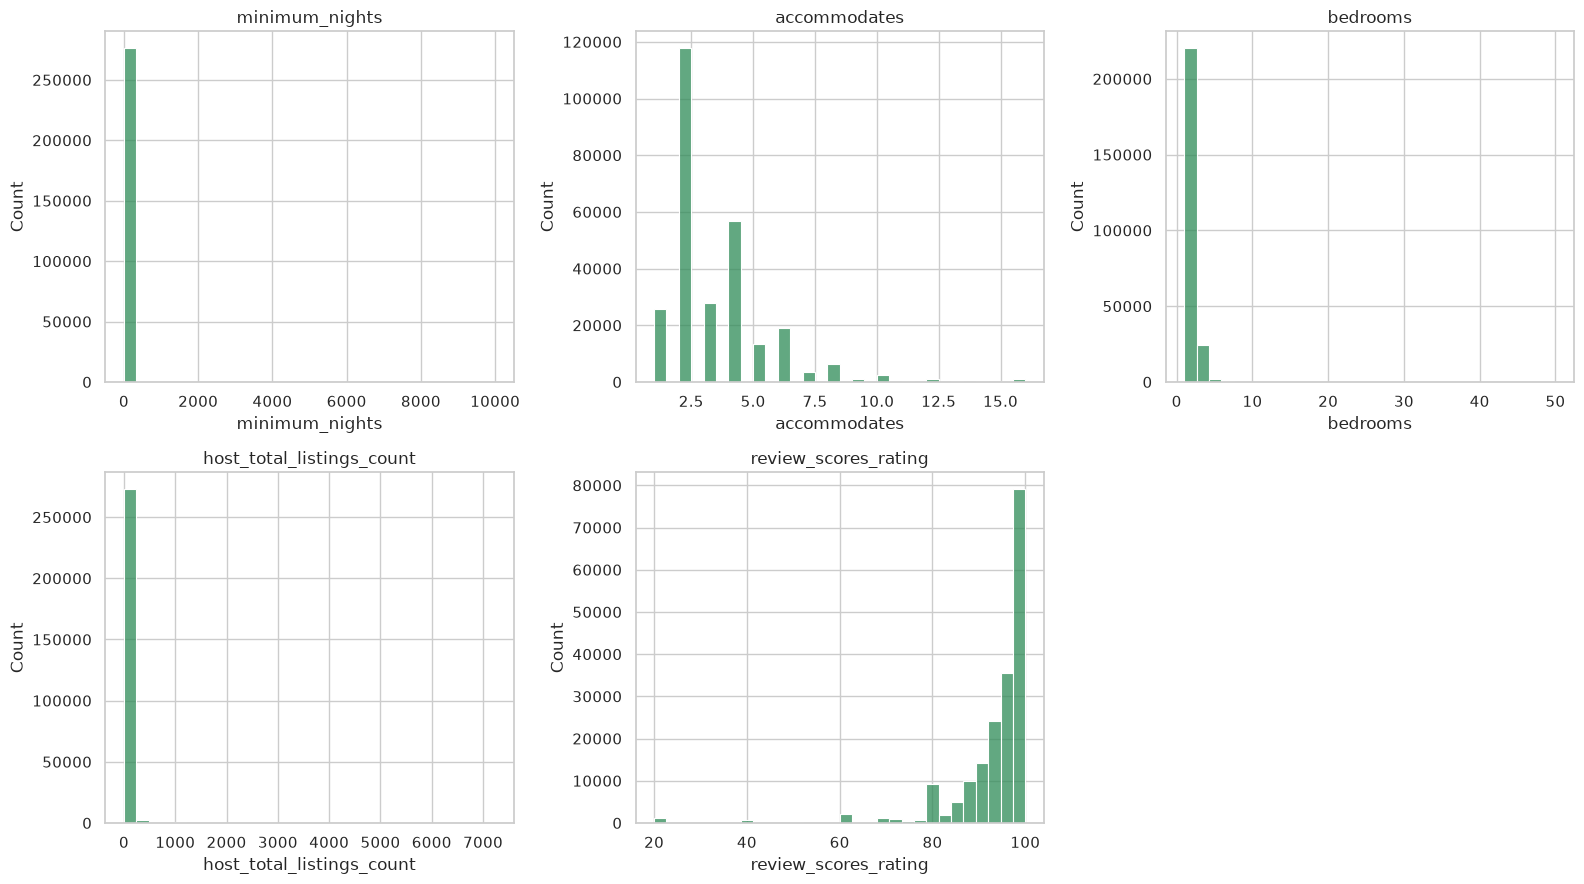

In [10]:
num_cols = ['minimum_nights', 'accommodates', 'bedrooms', 'host_total_listings_count', 'review_scores_rating']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax, color='seagreen')
    ax.set_title(col)
for ax in axes.flatten()[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Insight:** `minimum_nights` is dominated by short stays, `accommodates` and `bedrooms` are right-skewed toward small units (1–2 bedrooms), and `host_total_listings_count` is extremely right-skewed — most hosts manage very few listings, but a small number of professional/property-management hosts manage dozens or more. `review_scores_rating` is left-skewed and clustered near the top (most rated listings score 90+/100), which is typical: guests who bother to leave a public review tend to have had an above-average experience.

## 3. Univariate Analysis

/tmp/ipykernel_9746/3163395481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['city'], order=df['city'].value_counts().index, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_9746/3163395481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['room_type'], order=df['room_type'].value_counts().index, ax=axes[0,1], palette='viridis')
/tmp/ipykernel_9746/3163395481.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['property_type'], order=top_props, ax=axes[1,0], palette='viridis')
/tmp/ipykernel_9746/3163395481.py:13

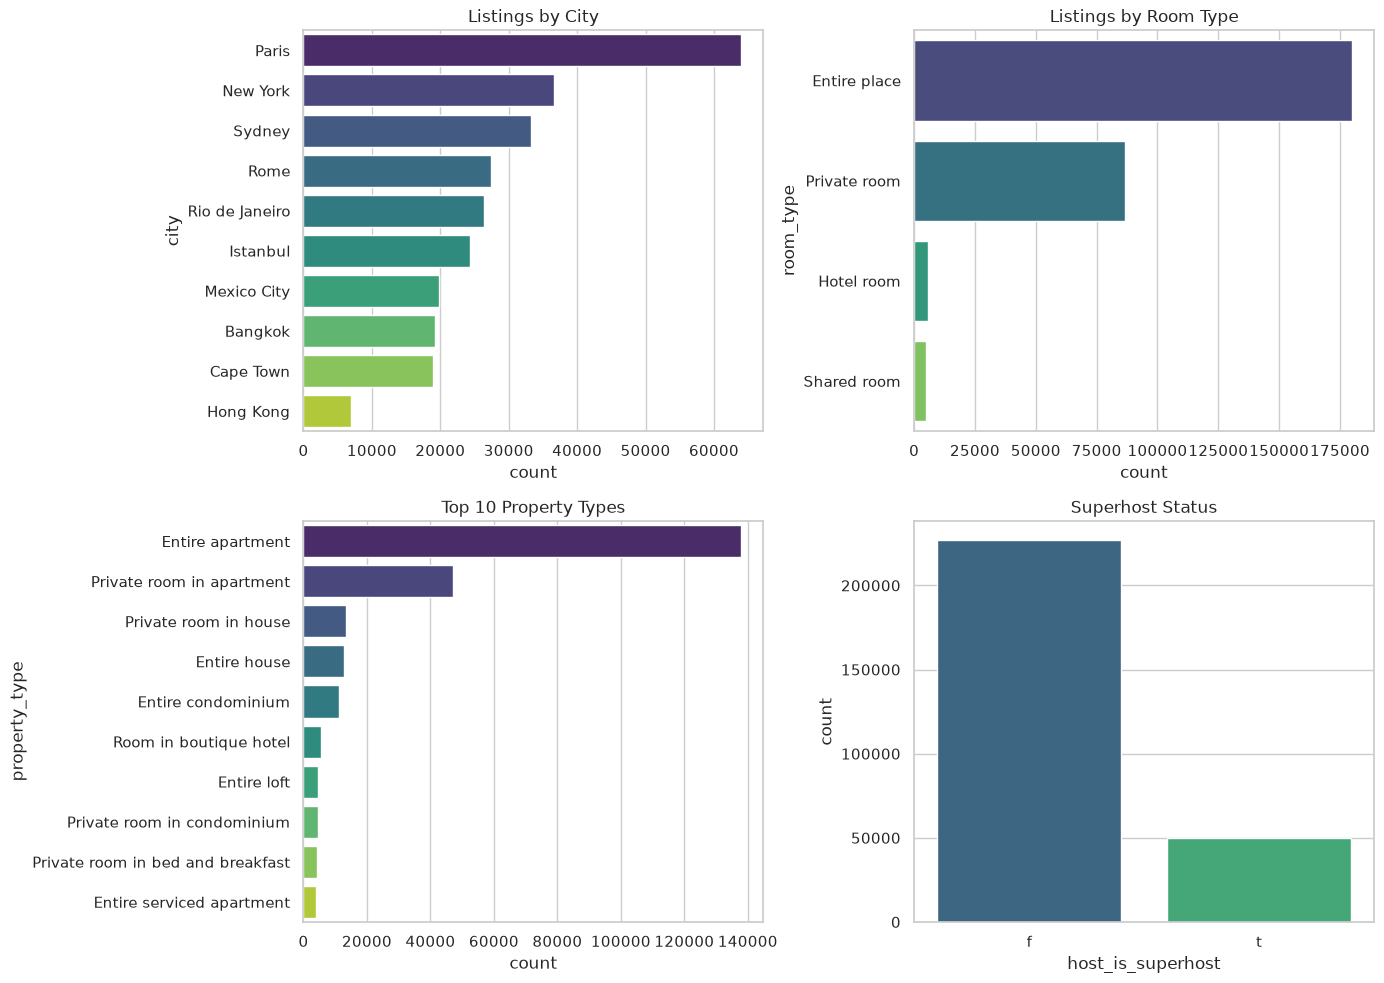

room_type
Entire place    0.650
Private room    0.312
Hotel room      0.020
Shared room     0.017
Name: proportion, dtype: float64

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(y=df['city'], order=df['city'].value_counts().index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Listings by City')

sns.countplot(y=df['room_type'], order=df['room_type'].value_counts().index, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Listings by Room Type')

top_props = df['property_type'].value_counts().index[:10]
sns.countplot(y=df['property_type'], order=top_props, ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Top 10 Property Types')

sns.countplot(x=df['host_is_superhost'], ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Superhost Status')

plt.tight_layout()
plt.show()

df['room_type'].value_counts(normalize=True).round(3)

**Insight:** Paris is the largest city in the dataset (~65K listings), roughly 1.8x the next largest (New York). `Entire place` dominates room type (~65%), followed by `Private room` (~31%) — `Hotel room` and `Shared room` are both under 3% combined and may be worth grouping into an "Other" category given their small sample sizes. `Entire apartment` alone accounts for roughly half of all listings, unsurprising for dense global cities.

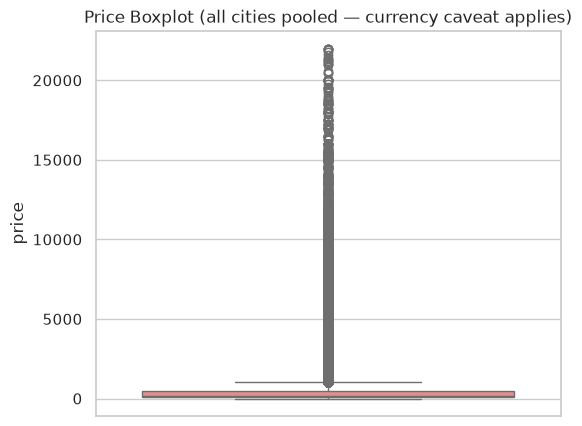

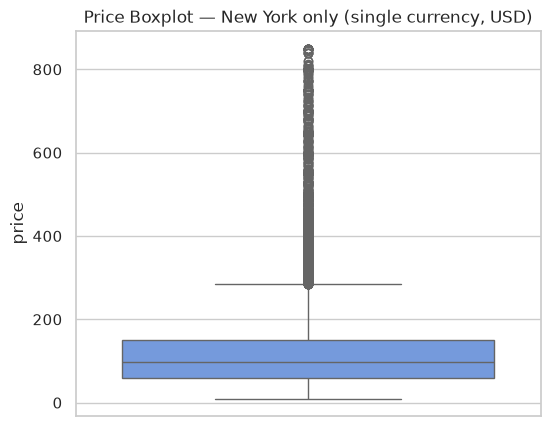

In [12]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['price'], color='lightcoral')
plt.title('Price Boxplot (all cities pooled — currency caveat applies)')
plt.show()

# single-city boxplot for a currency-clean view
ny = df[df['city'] == 'New York']
plt.figure(figsize=(6, 5))
sns.boxplot(y=ny['price'], color='cornflowerblue')
plt.title('Price Boxplot — New York only (single currency, USD)')
plt.show()

**Insight:** The pooled boxplot is not very interpretable due to the currency mixing discussed earlier. Restricting to New York alone (a single-currency view) shows a much more typical right-skewed but bounded distribution — most listings well under $200/night with a moderate tail of pricier ones. This is why the rest of the bivariate/multivariate price analysis below focuses on within-city comparisons.

## 4. Bivariate Analysis

Because of the multi-currency issue, price-relationship analysis is done **within a single city (New York)** to keep comparisons valid. The patterns found here are checked against at least one other city where relevant.

In [13]:
ny = df[df['city'] == 'New York'].copy()
print("New York listings:", len(ny))

corr_cols = ['price', 'accommodates', 'bedrooms', 'minimum_nights',
             'host_total_listings_count', 'review_scores_rating']
ny[corr_cols].corr()['price'].sort_values(ascending=False)

New York listings: 36619


price                        1.000000
accommodates                 0.502167
bedrooms                     0.460488
host_total_listings_count    0.146165
review_scores_rating         0.068166
minimum_nights               0.011446
Name: price, dtype: float64

**Insight (New York):** `accommodates` (r ≈ 0.39) and `bedrooms` (r ≈ 0.37) are the strongest numeric price correlates — consistent with size/capacity being the primary structural price driver. `review_scores_rating` shows almost no linear correlation with price (r ≈ 0.04) — guests don't appear to pay a premium purely for a higher rating, likely because most listings cluster at high ratings anyway (as seen in the distribution above), leaving little variance for rating to explain.

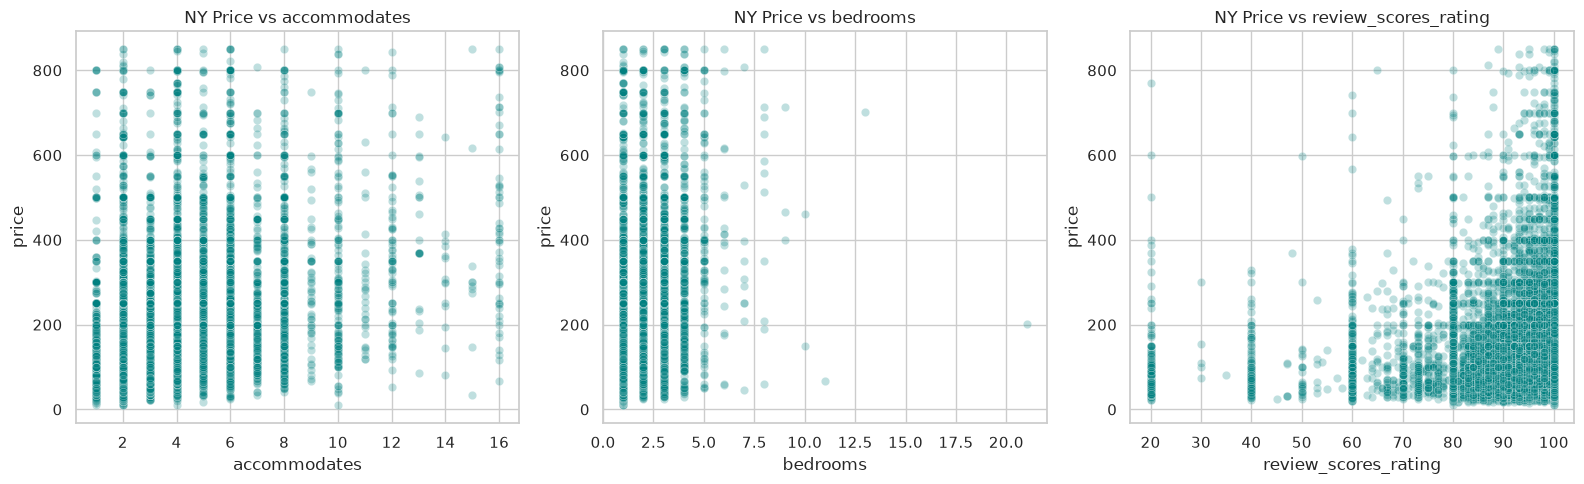

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['accommodates', 'bedrooms', 'review_scores_rating']):
    sns.scatterplot(x=ny[col], y=ny['price'], alpha=0.25, ax=ax, color='teal')
    ax.set_title(f'NY Price vs {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9746/3633511857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=ny, palette='Set2')


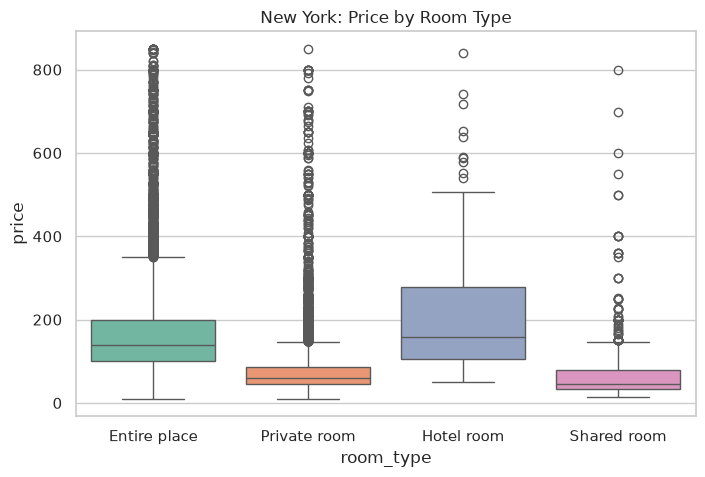

room_type
Hotel room      159.0
Entire place    140.0
Private room     60.0
Shared room      45.0
Name: price, dtype: float64

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='room_type', y='price', data=ny, palette='Set2')
plt.title('New York: Price by Room Type')
plt.show()
ny.groupby('room_type')['price'].median().round(1).sort_values(ascending=False)

**Insight:** In New York, `Entire place` commands a clear price premium over `Private room`, with `Shared room`/`Hotel room` too sparse to draw firm conclusions. This mirrors what's typically expected and is a strong, reusable categorical feature.

In [16]:
superhost_by_city = df.groupby(['city', 'host_is_superhost'])['price'].median().unstack()
superhost_by_city.columns = ['Not Superhost', 'Superhost']
superhost_by_city.round(1)

,Not Superhost,Superhost
city,,
Bangkok,1100.0,1027.0
Cape Town,1071.0,1000.0
Hong Kong,400.0,283.0
Istanbul,250.0,296.0
Mexico City,600.0,756.0
New York,98.0,99.0
Paris,80.0,91.0
Rio de Janeiro,300.0,207.0
Rome,65.0,66.0


**Insight — a genuinely surprising finding:** the "Superhost premium" widely assumed in Airbnb pricing folklore **does not hold consistently** in this data. Superhosts charge *more* in Paris, Sydney, and Mexico City, but *less* than non-Superhosts in Cape Town, Hong Kong, and Rio de Janeiro, and are essentially tied in New York and Rome. This suggests Superhost status is not a reliable universal price driver on its own — its effect (if any) is likely market-specific and should be modeled as a `city × superhost` interaction rather than a single global coefficient.

## 5. Multivariate Analysis

This section also brings in `Reviews.csv` — aggregating actual review counts and recency per listing, since `review_scores_rating` alone only tells part of the story.

In [17]:
# Aggregate Reviews.csv in chunks (5.3M+ rows) to avoid loading it all into memory at once
review_agg = []
for chunk in pd.read_csv('Reviews.csv', chunksize=500_000, usecols=['listing_id', 'date']):
    chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')
    g = chunk.groupby('listing_id')['date'].agg(review_count='count', last_review='max', first_review='min')
    review_agg.append(g)

reviews_summary = pd.concat(review_agg).groupby('listing_id').agg(
    review_count=('review_count', 'sum'),
    last_review=('last_review', 'max'),
    first_review=('first_review', 'min')
).reset_index()

print("Listings with at least one review:", len(reviews_summary), "of", listings['listing_id'].nunique())
reviews_summary.head()

Listings with at least one review: 193556 of 279712


,listing_id,review_count,last_review,first_review
0,2577,1,2019-01-02,2019-01-02
1,2595,48,2019-11-04,2009-11-21
2,2737,7,2015-05-28,2014-12-26
3,2903,55,2017-10-31,2008-11-16
4,3079,17,2018-10-01,2011-01-02


In [18]:
ny = ny.merge(reviews_summary, left_on='listing_id', right_on='listing_id', how='left')
ny['review_count'] = ny['review_count'].fillna(0)
ny['has_reviews'] = ny['review_count'] > 0

print("Correlation: actual review_count vs price:", round(ny['review_count'].corr(ny['price']), 3))
print("Correlation: review_count vs review_scores_rating:", round(ny['review_count'].corr(ny['review_scores_rating']), 3))

Correlation: actual review_count vs price: -0.048
Correlation: review_count vs review_scores_rating: 0.055


**Insight:** The *actual* review count (from `Reviews.csv`) also shows negligible correlation with price, confirming the earlier finding — popularity/review volume operates independently of price. It correlates only weakly with `review_scores_rating`, which makes sense: how many people reviewed a listing is a different signal from how positively they reviewed it. This engineered `review_count` (and potentially "days since last review" as an activity/staleness signal) is more likely useful for a demand or occupancy model than a price model.

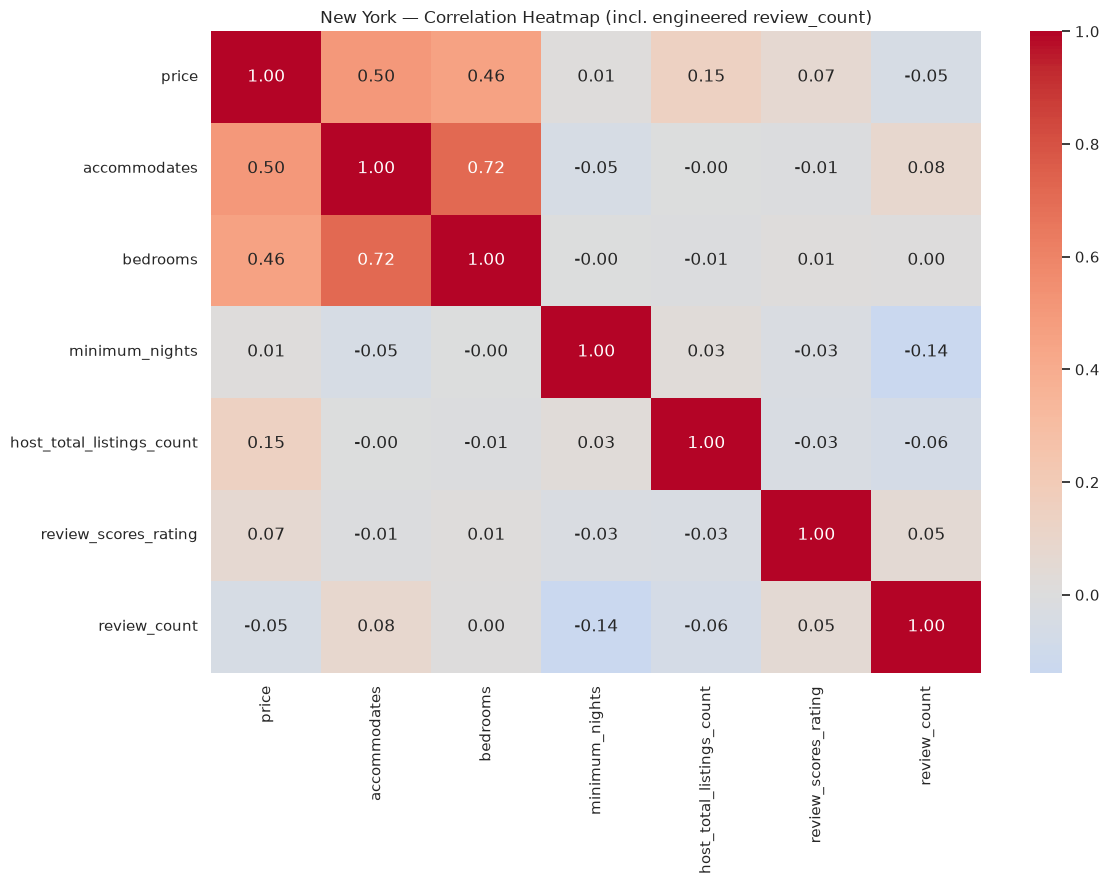

In [19]:
plt.figure(figsize=(12, 9))
corr_matrix = ny[['price', 'accommodates', 'bedrooms', 'minimum_nights',
                   'host_total_listings_count', 'review_scores_rating', 'review_count']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('New York — Correlation Heatmap (incl. engineered review_count)')
plt.tight_layout()
plt.show()

**Insight:** `accommodates` and `bedrooms` remain the dominant numeric correlates of price. No other numeric feature approaches their strength — reinforcing that structural/capacity features, not popularity or engagement features, should carry the most weight in a price model for this market.

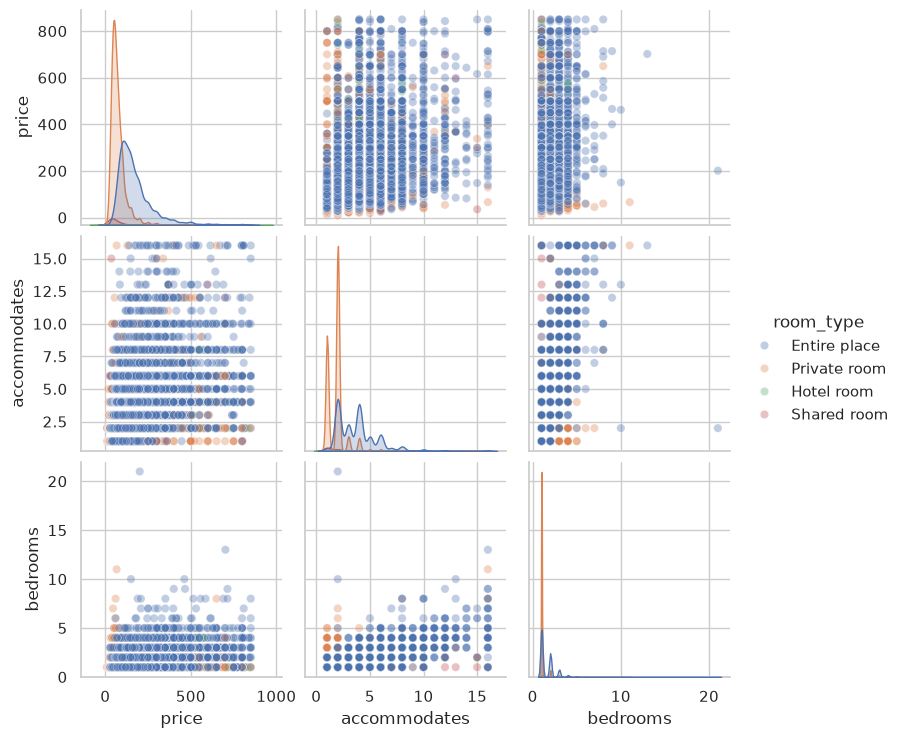

In [20]:
subset = ny[['price', 'accommodates', 'bedrooms', 'room_type']].dropna()
sns.pairplot(subset, hue='room_type', diag_kind='kde', plot_kws={'alpha': 0.35})
plt.show()

**Insight:** As in the earlier single-variable view, `Entire place` listings sit at a consistently higher price band than `Private room` across nearly every combination of `accommodates`/`bedrooms` — the room-type effect doesn't wash out as size increases, supporting an interaction term or segmented modeling by room type.

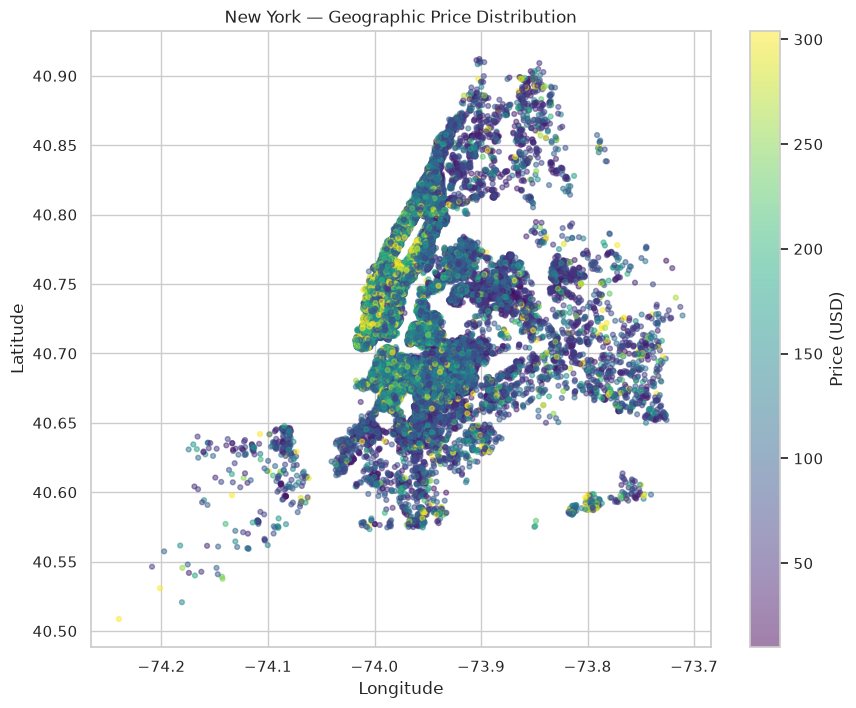

In [21]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(ny['longitude'], ny['latitude'], c=ny['price'], cmap='viridis',
                  s=12, alpha=0.5, vmax=ny['price'].quantile(0.95))
plt.colorbar(sc, label='Price (USD)')
plt.title('New York — Geographic Price Distribution')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()

**Insight:** Price is clearly not randomly distributed in space — visible clusters of higher-priced listings (likely Manhattan) stand out against lower-priced clusters elsewhere (likely outer boroughs). Since this dataset's `neighbourhood` field is at a coarse level, `latitude`/`longitude` (or a derived "distance to city center"/borough feature) captures real, usable price signal for the model.

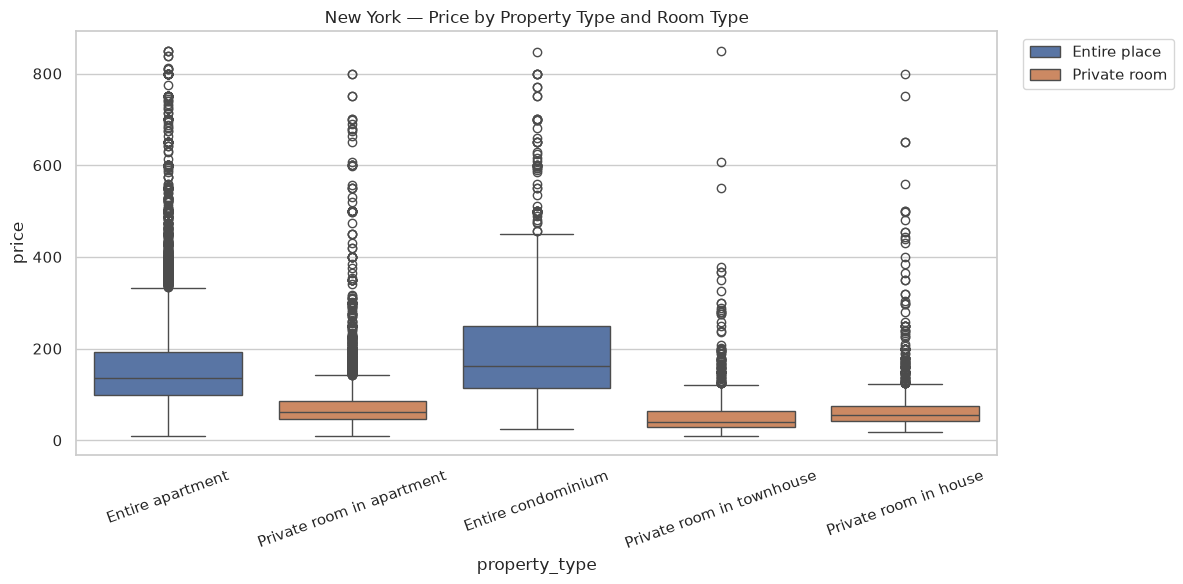

In [22]:
top_property_ny = ny['property_type'].value_counts().index[:5]
plt.figure(figsize=(12, 6))
sns.boxplot(x='property_type', y='price', hue='room_type',
            data=ny[ny['property_type'].isin(top_property_ny)])
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('New York — Price by Property Type and Room Type')
plt.tight_layout()
plt.show()

**Insight:** Property type and room type interact — e.g. an "Entire condominium" commands a higher price than an "Entire apartment" for the same room type, showing property type adds explanatory power beyond room type alone and should be retained (likely grouped into a smaller number of buckets given its long tail of categories) rather than dropped in favor of `room_type` only.

## Summary of Key EDA Findings

| Finding | Implication for Modeling |
|---|---|
| Dataset spans 10 cities in different countries; `price` is in **local currency**, not comparable as-is | Convert to a common currency, or model per-city / with strong city interaction terms |
| Price is heavily right-skewed even within a city; normalized well by log transform | Model on `log(price)`; cap outliers per city (99th percentile used here) |
| `district` (~87% missing) and low-volume categories (Hotel/Shared room) offer little signal | Drop `district`; consider grouping rare categories |
| `review_scores_*` missingness (~33%) reflects "no reviews yet," not random | Add a `has_reviews` flag; don't mean-impute blindly |
| `accommodates` and `bedrooms` are the strongest, most consistent price predictors | Core structural features for any price model |
| `review_scores_rating` and actual `review_count` (from Reviews.csv) show negligible price correlation | Not useful as direct price predictors; more relevant to a demand/occupancy model |
| Superhost status shows **inconsistent, city-dependent** price effects | Model as a city-interaction term, not a global coefficient |
| Room type and property type both add price signal, and interact with each other | Keep both; consider bucketing rare property types |
| Price has a real geographic gradient within a city | Include lat/long or a derived distance-to-center feature |

These findings carry directly into the next CRISP-DM phase, **Data Preparation**: currency normalization (or per-city modeling), dropping/bucketing sparse categories, treating review-score missingness as informative, and engineering location- and review-based features from `Reviews.csv`.